In [1]:
import os
import sys
import subprocess
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from pyarrow import fs
import pyarrow.parquet as pq
import pandas as pd
import numpy as np
import datetime
os.environ["HADOOP_CONF_DIR"] = "/path/to/hadoop/conf/"
os.environ["JAVA_HOME"] = "/path/to/java"
os.environ["HADOOP_HOME"] = "/path/to/hadoop"
os.environ["ARROW_LIBHDFS_DIR"] = "/path/to/hadoop/lib/"
os.environ["CLASSPATH"] = subprocess.check_output(
    "$HADOOP_HOME/bin/hadoop classpath --glob", shell=True
).decode("utf-8")

hdfs = fs.HadoopFileSystem(
    host="hdfs://your-hdfs-host", port=8020
)

# import pandas as pd
from tqdm import tqdm
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.simplefilter('ignore', ConvergenceWarning)
import sys

if not sys.warnoptions:
    import warnings

    warnings.simplefilter("ignore")
from tqdm import trange


2024-02-21 08:05:13,667 WARN util.NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import STL
from prophet import Prophet
import pandas as pd
from pmdarima import auto_arima


def measure_simility(arr1, arr2):
    arr1 = arr1.reshape((-1,))
    arr2 = arr2.reshape((-1,))
    score = np.corrcoef(arr1, arr2)[0, 1]
    return score


def pick_data_train(vt, arrs, n):
    score = []
    for arr in arrs:
        score.append(measure_simility(vt, arr))
    score = np.array(score)
    return np.argsort(score)[-n:], score[np.argsort(score)[-n:]]


def create_data_total(df, month, year, lag, shift):
    x_knowns = df[df.index < year].iloc[:, 11 + month - lag - shift: 11 + month - shift].values.reshape((-1, lag))
    # y_known = df[df.index == year].iloc[0,11 + month-lag: 11 +month].values
    y_known = df[df.index == year].iloc[0, 11 + month - lag: 11 + month].values
    # y_known = df.iloc[-1, 11 + month - lag: 11 + month].values
    x_news = df[df.index < year].iloc[:, 11 + month - shift].values
    # print(month,year,y_known)
    return x_knowns, y_known, x_news


def create_data_cumsum(df, month, year, lag, shift):
    x_knowns = df[df.index < year].iloc[:, 11 + month - lag - shift: 11 + month - shift].cumsum(axis=1).values.reshape(
        (-1, lag))
    y_known = df[df.index == year].iloc[:, 11 + month - lag: 11 + month].cumsum(axis=1).iloc[0, :].values
    # y_known = df.iloc[[-1], 11 + month - lag: 11 + month].cumsum(axis=1).iloc[0, :].values
    x_news = df[df.index < year].iloc[:, 11 + month - lag - shift: 12 + month - shift].cumsum(axis=1).iloc[:, -1].values
    return x_knowns, y_known, x_news


def create_data_rolling(df, month, year, lag, shift, n_rolling):
    y_old = df[df.index == year].iloc[0, 11 + month - 1 - n_rolling + 1:11 + month - 1].sum()
    df = df.rolling(n_rolling, axis=1).mean()
    x_knowns = df[df.index < year].iloc[:, 11 + month - lag - shift: 11 + month - shift].values.reshape((-1, lag))
    y_known = df[df.index == year].iloc[0, 11 + month - lag: 11 + month].values
    x_news = df[df.index < year].iloc[:, 11 + month - shift].values
    return x_knowns, y_known, x_news, y_old


def predict_total(known_y, known_x, new_x, order):
    # known_y = known_y.reshape((-1,))
    # known_x = known_x.reshape((-1,))
    coefficients = np.polyfit(known_x, known_y, order)
    estimated_func = np.poly1d(coefficients)
    return float(estimated_func(new_x))


def predict_cumsum(known_y, known_x, new_x, order):
    # known_y = known_y.reshape((-1,))
    # known_x = known_x.reshape((-1,))
    coefficients = np.polyfit(known_x, known_y, order)
    estimated_func = np.poly1d(coefficients)
    return float(estimated_func(new_x))


def predict(df_total, year, month: int, lag: int, order1: int, order2: int, shift: int, n_max):
    x_knowns, y_known, x_news = create_data_total(df_total, month, year, lag, shift)
    max_scores, coeffs = pick_data_train(y_known, x_knowns, n_max)
    pre = []
    for max_score in max_scores:
        x_knowns, y_known, x_news = create_data_total(df_total, month, year, lag, shift)
        x_known = x_knowns[max_score]
        x_new = x_news[max_score]

        pred1 = predict_total(known_y=y_known,
                              known_x=x_known,
                              new_x=x_new, order=order1)
        pre.append(pred1)
        shift = 0
        x_knowns, y_known, x_news = create_data_cumsum(df_total, month, year, lag, shift)
        x_known = x_knowns[max_score]
        x_new = x_news[max_score]
        pred2 = predict_cumsum(known_y=y_known,
                               known_x=x_known,
                               new_x=x_new, order=order2) - y_known[-1]

        pre.append(pred2)
    return np.mean(pre), coeffs.mean()


def predict_master(data: pd.DataFrame, d_date: pd.DataFrame, month, year, lag, p, d, q, n_max, type_decomp,
                   methods_season, method_resid, method_trend,order1,order2):
    date = f"{year}-{month}-1"
    # print(date)
    # d_train = data[data.index < f"{year}-1-1"]
    d_train = data[data.index < date]
    d_train = pd.concat([d_train, d_date], axis=1).dropna(axis=0)

    d_residuals, d_trend, d_seasonal = detrend(d_train, type=type_decomp)
    # y_residual=0
    y_residual = forecast_residual(d_residuals.values, p, d, q, method_resid=method_resid)
    # except:
    #     y_residual = 0

    d_seasonal.name = name_province
    # d_seasonal = pd.concat([d_seasonal, d_date], axis=1)
    d_seasonal = pd.concat([d_seasonal, d_date], axis=1).fillna(0)
    d_seasonal = d_seasonal.pivot_table(columns='month', index='year', values=name_province)
    y_seasonal = forecast_seasonal(d_seasonal, month, year, lag, n_max,order1,order2, methods_season)

    d_trend.name = name_province
    d_trend = pd.concat([d_trend, d_date], axis=1).dropna()
    y_trend = forecast_trend(d_trend.iloc[-2, 0], d_trend.iloc[-1, 0], method_trend=method_trend)

    # d_residuals = pd.concat([d_residuals, d_date], axis=1).dropna()
    # y_re3 = d_seasonal.pivot_table(columns='month', index='year', values=name_province).dropna(axis=0).mean(axis=0)[
    #     month]
    # d_residuals = d_residuals.pivot_table(columns='month', index='year', values=name_province)
    # d_trend = d_trend.pivot_table(columns='month', index='year', values=name_province)
    # y_re2 = forecast_seasonal(d_trend, month, year, lag, 2)
    # return y_lr + (y_re1 +y_re2+y_re)/3,y_re
    # return (y_re3 + y_re1) / 2 + y_re2
    return y_trend, y_seasonal, y_residual


def detrend(df: pd.DataFrame, type='STL'):
    if type == 'STL':
        data = df.copy()
        data = data.iloc[:, 0]
        stl = STL(data,period=12)
        res = stl.fit()
        trend = res.trend
        resid = res.resid
        season = res.seasonal
        return resid, trend, season
    if type == 'prophet':
        data = df.copy()
        data = data.iloc[:, [0]]
        data = data.reset_index()
        data.columns = ['ds', 'y']
        model = Prophet(yearly_seasonality=12)
        model.fit(data)
        forecaster = model.predict(model.make_future_dataframe(periods=0, freq='MS'))
        forecaster['y'] = data['y']
        forecaster['resid'] = forecaster.apply(lambda row: (row.y - (row.yearly + row.trend)), axis=1)
        forecaster = forecaster.set_index('ds')
        df_resid = forecaster['resid']
        df_trend = forecaster['trend']
        df_season = forecaster['yearly']
        df_season.name = 'seasonal'
        return df_resid, df_trend, df_season
    else:
        return None, None, None


def compute_error(data, month, year, y_pr):
    y_tr = data[data.index == f'{year}-{month}-1'].values[0]
    return (y_pr - y_tr) / y_tr, y_tr


def forecast_seasonal(data, month, year, lag, n_max,order1,order2, method='statistics'):
    if method == 'statistics':
        df = data.copy()
        df = pd.concat([df.shift(1, axis=0), df, df.shift(-1, axis=0)], axis=1).iloc[1:, :] + 10e10
        # lag = int(params[month - 1][1])
        # shift = int(params[month - 1][2])
        # order1 = int(params[month - 1][3])
        # order2 = int(params[month - 1][4])
        # lag = 6
        shift = 0
        # order1 = 1
        # order2 = 1
        y, _ = predict(df, year, month, lag, order1, order2, shift, n_max)
        return y - 10e10
    if method == 'average':
        df = data.copy()
        # df = df[df.index<year]
        # print(df.dropna(axis=0).mean(axis=0))
        y = df.dropna(axis=0).mean(axis=0)[month]
        # print(y)
        return y
    if method == 'latest':
        df = data.copy()
        # df = df[df.index<year]
        # print(df.dropna(axis=0).mean(axis=0))
        y = df.dropna(axis=0).iloc[-1, :][month]
        # print(y)
        return y
    else:
        raise "Not specify the season method"


def forecast_trend(y_1, y_t, method_trend='average'):
    if method_trend == 'average':
        y_pr_trend = y_t + (y_t - y_1)
        # y_pr_trend = y_t
        return y_pr_trend
    if method_trend == 'latest':
        return y_t
    else:
        raise "Not specify the trend method"


def forecast_residual(series, p, d, q, method_resid='arima'):
    if method_resid == 'arima':
        try:
            model = ARIMA(series, order=(p, d, q))
            model_fit = model.fit()
            return model_fit.forecast(freq='MS')[0]
        except:return 0
    # if method_resid == 'autoarima':
    #     model = auto_arima(series, seasonal=False, trace=False)
    #     return model.predict(n_periods=1, freq='MS')[0]
    else:
        return 0


def get_ytr(df, month, year):
    try:
        filter = f'{year}-{month}-01'
        return df[df.index == filter].values[0][0]
    except:
        return None


In [4]:
! hdfs dfs -ls /path/to/company_data/user/<user>/CPC/SL_MDD_1M.parquet

Found 11 items
drwxrwx---+  - <user> fdp          0 2024-02-20 09:10 /path/to/company_data/user/<user>/CPC/SL_MDD_1M.parquet/Y=2014
drwxrwx---+  - <user> fdp          0 2024-02-20 09:10 /path/to/company_data/user/<user>/CPC/SL_MDD_1M.parquet/Y=2015
drwxrwx---+  - <user> fdp          0 2024-02-20 09:10 /path/to/company_data/user/<user>/CPC/SL_MDD_1M.parquet/Y=2016
drwxrwx---+  - <user> fdp          0 2024-02-20 09:10 /path/to/company_data/user/<user>/CPC/SL_MDD_1M.parquet/Y=2017
drwxrwx---+  - <user> fdp          0 2024-02-20 09:10 /path/to/company_data/user/<user>/CPC/SL_MDD_1M.parquet/Y=2018
drwxrwx---+  - <user> fdp          0 2024-02-20 09:10 /path/to/company_data/user/<user>/CPC/SL_MDD_1M.parquet/Y=2019
drwxrwx---+  - <user> fdp          0 2024-02-20 09:10 /path/to/company_data/user/<user>/CPC/SL_MDD_1M.parquet/Y=2020
drwxrwx---+  - <user> fdp          0 2024-02-20 09:10 /path/to/company_data/user/<user>/CPC/SL_MDD_1M.parquet/Y=2021
drwxrwx---+  - <user> fdp          0 2024-02-20 0

In [15]:
df_sl_13province = pd.DataFrame()
for year in range(2014,2025):
    df_each_year = pd.read_parquet("/path/to/company_data/user/<user>/CPC/SL_MDD_1M.parquet/Y={}".format(year),
                filesystem=hdfs)
    df_each_year['year'] = year
    print(df_each_year.shape)
    df_sl_13province = pd.concat([df_sl_13province,df_each_year],axis=0)
    # break
df_sl_13province['date'] = df_sl_13province.apply(lambda row: f"{row['year']}-{row['M']}-1",axis=1)
df_sl_13province['date'] = pd.to_datetime(df_sl_13province['date'])
df_sl_13province = df_sl_13province.pivot_table(index='date',columns='MA_DDO',values='SAN_LUONG')

(9307, 13)
(10498, 13)
(11900, 13)
(13273, 13)
(14744, 13)
(16408, 13)
(17825, 13)
(18868, 13)
(19212, 13)
(20076, 13)
(1666, 13)


<AxesSubplot: xlabel='year,M'>

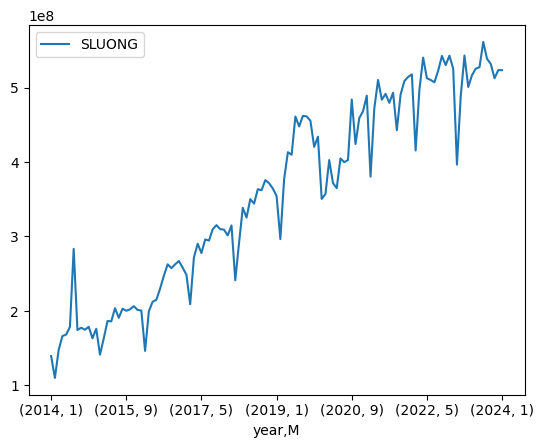

In [19]:
df_sl_13province.groupby(['year','M']).agg(SLUONG=('SAN_LUONG','sum')).plot()

In [3]:
df_sl_13province = pd.read_parquet(
    "/path/to/company_data/sa/cpc/store/data/SUM_TOTAL/total_sl_13_provinces.parquet",
    filesystem=hdfs,
)
df_total = df_sl_13province.copy().iloc[:, :-2]
df_total.sort_index(ascending=False)

,BDINH,DANANG,DLAC,DNONG,GLAI,KHOA,KTUM,PYEN,QBINH,QNAM,QNGAI,QTRI,TTHUE
2023-09-01,245839910,334853775,176063087,54283312,110191783,260444740,43581322,100937390,98962439,236474490,204920013,77906522,178190905
2023-08-01,242369036,343785390,165399531,56374080,102936424,265528697,41840936,102246544,110525322,240610425,215246731,76453922,199127317
2023-07-01,233235735,326926273,225670967,54001966,99612551,257294123,35742815,98088703,113621328,235488889,208611398,76141968,198830608
2023-06-01,228823421,330680715,168812969,53316010,107390568,271509827,36895142,96097851,110674072,227709151,194811747,76724152,195177149
2023-05-01,216806344,286066168,187140663,60349930,117451433,247772333,38467958,92300982,94728487,218021212,199729737,66608424,175060653
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-05-01,109020851,174787775,79342405,25359790,59053431,133281730,19117542,53233202,42541591,85474822,65868671,35176768,83298265
2014-04-01,106980799,162856212,105691355,29143732,69987127,129094178,21582720,51224448,38001848,79521511,57405645,33058614,77229218
2014-03-01,89933134,142248291,102318681,28428148,66854058,104901205,21179978,40911196,31825578,69499584,53839918,28804559,70880304
2014-02-01,82798961,118504214,94361317,27277756,62212335,99327977,19357363,39385612,31836806,64626800,49076635,29065610,64868611


In [27]:
month_standing = df_total.index.max().month  # month is standing to forecast
df_total_padding = pd.DataFrame({col: None for col in df_total.columns},
                                index=pd.date_range(start=df_total.index.max() + datetime.timedelta(days=32), end=df_total.index.max() + datetime.timedelta(days=400), freq='MS'))
df_total_final = pd.concat([df_total, df_total_padding], axis=0)
# df_total_final

In [28]:
date_range = pd.date_range(start=df_total.index.min(), end=df_total.index.max() + datetime.timedelta(days=400), freq='MS')
df_datetime = pd.DataFrame({'stt': [i for i in range(df_total_final.shape[0])]}, index=df_total_final.index)
df_datetime['month'] = df_datetime.index.month
df_datetime['year'] = df_datetime.index.year

In [29]:
dfp = pd.read_parquet(
    '/path/to/company_data/user/<user>/cpc/data/parameter/final_params_13province_u2022.parquet',
    filesystem=hdfs)

In [30]:
lst_pr = df_total_final.columns
df_result = pd.DataFrame()
years = [2023]
for n_province in trange(len(lst_pr)):
    # for n_province in [1]:
    # df = df_total.iloc[:, [n_province]]
    name_province = lst_pr[n_province]
    try:
        dp = dfp[dfp.province == name_province]
        lag = 6
        # n_max = 2
        n_max = dp.n_max.values[0]
        # type_decomp = dp.type_decomp.values[0]
        # method_season =dp.method_season.values[0]
        method_trend = dp.method_trend.values[0]
        method_resid = dp.method_resid.values[0]
        # n_max = 5
        type_decomp = 'STL'
        method_season = 'statistics'
        p = 1
        d = 0
        q = 1
        # df = df.sort_index()
        # print(name_province)
    except:
        lag = 6
        n_max = 5
        method_trend = 'average'
        method_season = 'statistics'
        type_decomp = 'STL'
        method_resid = 'arima'
        p = 1
        d = 0
        q = 1

    for year in years:
        for month in range(1, 2):
            # print(month)
            if pd.to_datetime(f"{year}-{month}") > pd.to_datetime(f"{df_total.index.max().year}-{df_total.index.max().month+1}"):
                break
            # try:
            # print(month)
            lst_ypr = []
            lst_ytr = []
            lst_trend = []
            lst_resid = []
            lst_season = []
            df = df_total_final.copy().iloc[:, [n_province]]
            df = df.sort_index()
            for t in range(1):
            # for t in range(12):
                # try:
                # print(t)
                if (month + t > 12):
                    year = year + 1
                    month = month - 12
                    # print(month)

                    y_trend, y_seasonal, y_residual = predict_master(
                        data=df,
                        d_date=df_datetime,
                        month=month+t, year=year,
                        lag=lag, p=p, d=d, q=q,
                        n_max=n_max,
                        type_decomp=type_decomp,
                        methods_season=method_season, method_resid=method_resid,
                        method_trend=method_trend,order1=1,
                        order2=1)
                    y_tr = get_ytr(df, month + t, year)
                    y_pr = y_trend + y_seasonal + y_residual

                    df.at[f"{year}-{month + t}-1", name_province] = y_pr
                    year = year - 1
                    month = month + 12
                else:
                    y_trend, y_seasonal, y_residual = predict_master(
                        data=df,
                        d_date=df_datetime,
                        month=month + t, year=year,
                        lag=lag, p=p, d=d, q=q,
                        n_max=n_max,
                        type_decomp=type_decomp,
                        methods_season=method_season, method_resid=method_resid,
                        method_trend=method_trend,order1=1,
                        order2=1)

                    y_tr = get_ytr(df, month + t, year)
                    y_pr = y_trend + y_seasonal + y_residual

                    df.at[f"{year}-{month + t}-1", name_province] = y_pr

                lst_ypr.append(y_pr)
                lst_ytr.append(y_tr)
                lst_trend.append(y_trend)
                lst_season.append(y_seasonal)
                lst_resid.append(y_residual)

            # except:
            #
            #     print(year,month,t)
            #     break
            df_result = pd.concat([df_result, pd.DataFrame({
                'province': [name_province],
                'year': [year],
                'month': [month],
                'trend': [lst_trend],
                'season': [lst_season],
                'resid': [lst_resid],
                'y_pr': [lst_ypr],
                'y_tr': [lst_ytr],
                'n_max': [n_max],
            })])
        # except:break


  2%|▏         | 33/1630 [00:02<01:44, 15.31it/s]


IndexError: index -2 is out of bounds for axis 0 with size 0

In [12]:
def expand_ypr(row):
    row = row['y_pr']
    return row[0], row[1], row[2], row[3], row[4], row[5], row[6], row[7], row[8], row[9], row[10], row[11]


def expand_ytr(row):
    row = row['y_tr']
    return row[0], row[1], row[2], row[3], row[4], row[5], row[6], row[7], row[8], row[9], row[10], row[11]


df_result[['y_pr1', 'y_pr2', 'y_pr3', 'y_pr4', 'y_pr5', 'y_pr6', 'y_pr7', 'y_pr8', 'y_pr9', 'y_pr10', 'y_pr11',
           'y_pr12', ]] = df_result.apply(expand_ypr, axis=1, result_type='expand')
df_result[['y_tr1', 'y_tr2', 'y_tr3', 'y_tr4', 'y_tr5', 'y_tr6', 'y_tr7', 'y_tr8', 'y_tr9', 'y_tr10', 'y_tr11',
           'y_tr12', ]] = df_result.apply(expand_ytr, axis=1, result_type='expand')

In [13]:
df_result

,province,year,month,trend,season,resid,y_pr,y_tr,n_max,y_pr1,...,y_tr3,y_tr4,y_tr5,y_tr6,y_tr7,y_tr8,y_tr9,y_tr10,y_tr11,y_tr12
0,BDINH,2023,1,"[205557633.5085091, 206782784.433132, 20856845...","[-22390013.59336853, -32575777.536849976, -168...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[183167619.91514057, 174207006.89628202, 19167...","[151273527, 177946236, 176858876, 201068892, 2...",5,1.831676e+08,...,176858876.0,201068892.0,216806344.0,228823421.0,233235735.0,242369036.0,245839910.0,NaN,NaN,NaN
0,DANANG,2023,1,"[279579307.1373067, 282068562.8475487, 2828704...","[-34558718.70222473, -55888992.352142334, -382...","[-184169.85790848453, -3571500.227286652, -161...","[244836418.57717347, 222608070.26811972, 24301...","[198020079, 214893731, 226760150, 263559396, 2...",5,2.448364e+08,...,226760150.0,263559396.0,286066168.0,330680715.0,326926273.0,343785390.0,334853775.0,NaN,NaN,NaN
0,DLAC,2023,1,"[166528955.89694446, 165377394.37490153, 16570...","[-10277078.704711914, 14550262.104278564, 3382...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[156251877.19223255, 179927656.4791801, 199529...","[146636791, 180960612, 203534636, 199224576, 1...",5,1.562519e+08,...,203534636.0,199224576.0,187140663.0,168812969.0,225670967.0,165399531.0,176063087.0,NaN,NaN,NaN
0,DNONG,2023,1,"[53304423.15386725, 53894592.415327266, 552519...","[5633882.1332092285, 6684443.112426758, 352603...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[58938305.28707648, 60579035.52775402, 5877796...","[53847077, 56518311, 66101270, 65639152, 60349...",5,5.893831e+07,...,66101270.0,65639152.0,60349930.0,53316010.0,54001966.0,56374080.0,54283312.0,NaN,NaN,NaN
0,GLAI,2023,1,"[109479717.39484161, 111727712.85380504, 11216...","[268411.4591064453, 7694440.020477295, 1144876...","[150734.92554459386, 535512.5730014723, -58467...","[109898863.77949265, 119957665.4472838, 123030...","[105299120, 127776662, 128307269, 130167448, 1...",5,1.098989e+08,...,128307269.0,130167448.0,117451433.0,107390568.0,99612551.0,102936424.0,110191783.0,NaN,NaN,NaN
0,KHOA,2023,1,"[218977831.42791015, 220074157.25921008, 22090...","[-27106562.064666748, -31269947.44052124, -273...","[-801688.5914139517, -1210560.2547108964, -973...","[191069580.77182946, 187593649.56397796, 19256...","[175283917, 189895964, 184038612, 227449218, 2...",5,1.910696e+08,...,184038612.0,227449218.0,247772333.0,271509827.0,257294123.0,265528697.0,260444740.0,NaN,NaN,NaN
0,KTUM,2023,1,"[40802195.76017411, 41219629.49109402, 4183167...","[2838263.2497406006, -179398.69189453125, 2301...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[43640459.00991471, 41040230.79919949, 4413329...","[37145284, 44333930, 43112378, 41131770, 38467...",2,4.364046e+07,...,43112378.0,41131770.0,38467958.0,36895142.0,35742815.0,41840936.0,43581322.0,NaN,NaN,NaN
0,PYEN,2023,1,"[84552121.34400383, 85169011.73668924, 8548862...","[-11035855.24256897, -10125441.141159058, -862...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[73516266.10143486, 75043570.59553018, 7686178...","[65468067, 75283258, 70798413, 86219002, 92300...",2,7.351627e+07,...,70798413.0,86219002.0,92300982.0,96097851.0,98088703.0,102246544.0,100937390.0,NaN,NaN,NaN
0,QBINH,2023,1,"[92776349.73633799, 92448377.9147299, 92776567...","[-11533159.147277832, -14810731.032470703, -15...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[81243190.58906016, 77637646.88225919, 7776211...","[69778375, 78252746, 78360077, 86843318, 94728...",2,8.124319e+07,...,78360077.0,86843318.0,94728487.0,110674072.0,113621328.0,110525322.0,98962439.0,NaN,NaN,NaN
0,QNAM,2023,1,"[213362730.9230895, 213970225.43290988, 214237...","[-20472756.884109497, -35694111.92683411, -217...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[192889974.03898, 178276113.50607577, 19251066...","[159442137, 182032501, 187461080, 207988729, 2...",5,1.928900e+08,...,187461080.0,207988729.0,218021212.0,227709151.0,235488889.0,240610425.0,236474490.0,NaN,NaN,NaN


In [51]:
for dt in pd.date_range(start=f"{df_total.index.max().year}-{df_total.index.max().month+1}",end=f"{df_total.index.max().year}-{df_total.index.max().month+1}",freq='MS'):
    print(dt.month)
    print(dt.year)
    print(type(dt.year))

10
2023
<class 'int'>


In [4]:
pd.read_parquet('/path/to/company_data/user/<user>/cpc/result/202309/fct_12t_sum_13province_test_2023.parquet',filesystem=hdfs)

,province,year,month,trend,season,resid,y_pr,y_tr,n_max,y_pr1,...,y_tr3,y_tr4,y_tr5,y_tr6,y_tr7,y_tr8,y_tr9,y_tr10,y_tr11,y_tr12
0,BDINH,2023,5,"[199682240.19379044, 198629225.6447025, 196753...","[3404802.6127319336, 22883302.944335938, 23063...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[203087042.80652237, 221512528.58903843, 21981...","[216806344.0, 228823421.0, 233235735.0, 242369...",5,2.030870e+08,...,233235735.0,242369036.0,245839910.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,BDINH,2023,6,"[201345676.9185022, 200076297.58566728, 199426...","[23788442.09954834, 23762955.75894165, 2340893...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[225134119.01805055, 223839253.34460893, 22283...","[228823421.0, 233235735.0, 242369036.0, 245839...",5,2.251341e+08,...,242369036.0,245839910.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,BDINH,2023,7,"[200806787.32626066, 200263349.4854532, 200720...","[23720572.722244263, 23610319.94555664, 212900...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[224527360.04850492, 223873669.43100983, 22201...","[233235735.0, 242369036.0, 245839910.0, nan, n...",5,2.245274e+08,...,245839910.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,BDINH,2023,8,"[201987626.39467376, 202608548.82692614, 20416...","[23068288.419525146, 20207558.072128296, 57396...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[225055914.8141989, 222816106.89905444, 209908...","[242369036.0, 245839910.0, nan, nan, nan, nan,...",5,2.250559e+08,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,DANANG,2023,5,"[271209334.8785167, 270731772.82093215, 271104...","[-338906.486907959, 47530594.188690186, 522312...","[-248465.56688544533, -1312255.1625709836, 536...","[270621962.82472324, 316950111.8470513, 323871...","[286066168.0, 330680715.0, 326926273.0, 343785...",5,2.706220e+08,...,326926273.0,343785390.0,334853775.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,DANANG,2023,6,"[273789758.8093985, 275502319.7438949, 2770898...","[49645703.33961487, 53249466.41511536, 4694348...","[913259.2439979909, -153627.4470748384, 514915...","[324348721.39301133, 328598158.7119354, 324548...","[330680715.0, 326926273.0, 343785390.0, 334853...",5,3.243487e+08,...,343785390.0,334853775.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,DANANG,2023,7,"[276756068.11961424, 278780368.2708078, 280956...","[53455216.690216064, 47255698.874816895, 31297...","[851511.3214651648, 72140.18477419061, -77963....","[331062796.1312955, 326108207.3303989, 3121760...","[326926273.0, 343785390.0, 334853775.0, nan, n...",5,3.310628e+08,...,334853775.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,DANANG,2023,8,"[277961327.82302314, 279915376.55677557, 28337...","[47458748.73899841, 31278172.443359375, 111791...","[-603459.122255261, 283849.63653755095, 745766...","[324816617.4397663, 311477398.6366725, 2953047...","[343785390.0, 334853775.0, nan, nan, nan, nan,...",5,3.248166e+08,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,DLAC,2023,5,"[168461738.84167004, 172553379.70492005, 17587...","[13979268.32145691, -2410896.589553833, -10044...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[182441007.16312695, 170142483.11536622, 16582...","[187140663.0, 168812969.0, 225670967.0, 165399...",5,1.824410e+08,...,225670967.0,165399531.0,176063087.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,DLAC,2023,6,"[173483921.71317953, 176846190.23179224, 17802...","[-2934774.3293914795, -10540837.674499512, -14...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[170549147.38378805, 166305352.55729273, 16358...","[168812969.0, 225670967.0, 165399531.0, 176063...",5,1.705491e+08,...,165399531.0,176063087.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
